In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV


In [2]:

df = pd.read_csv("Breast Cancer Data.csv")

print("Dataset Overview:")
print(df.head())
print("\nColumn Information:")
print(df.info())


Dataset Overview:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area

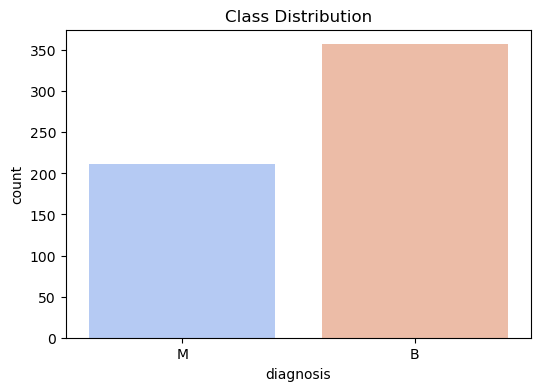

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["diagnosis"], palette="coolwarm")
plt.title("Class Distribution")
plt.show()

id                           int64
diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

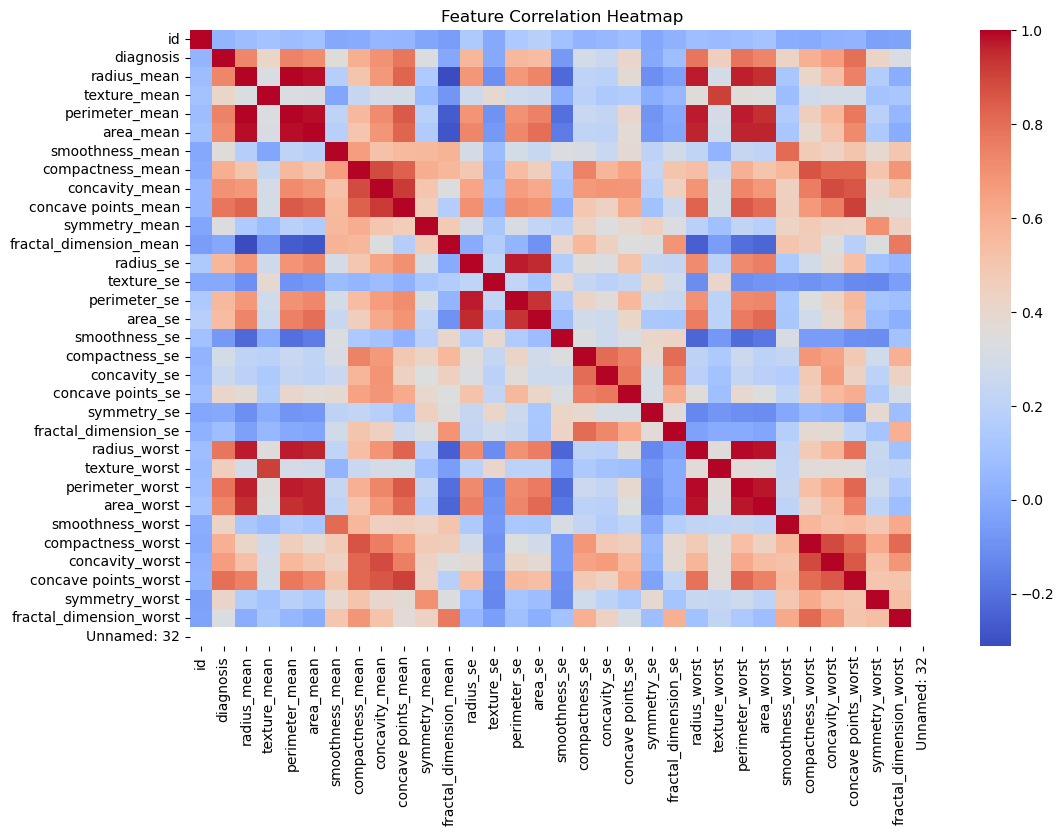

In [4]:
X = df.drop(columns=["diagnosis"])  
y = df["diagnosis"]


df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

print(df.dtypes)


plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [5]:

df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')


label_encoder = LabelEncoder()
df['diagnosis'] = label_encoder.fit_transform(df['diagnosis'])


X = df.drop(columns=['diagnosis'], errors='ignore')
y = df['diagnosis']


if X.empty:
    raise ValueError("Error: No features left after dropping columns. Check dataset structure!")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nXGBoost Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)



XGBoost Model Accuracy: 0.9649

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



C:\Users\91636\AppData\Roaming\Python\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


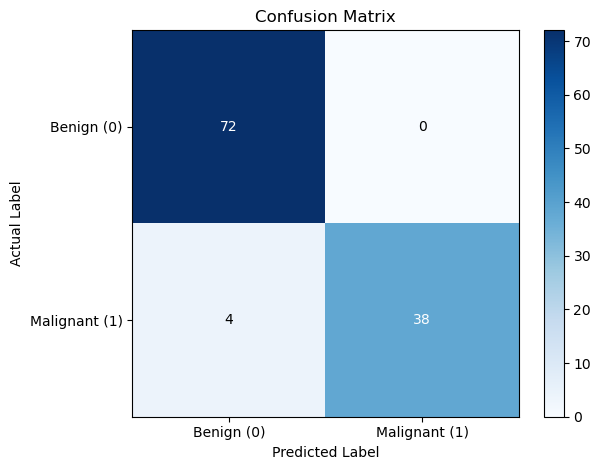

In [6]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, labels=["Benign (0)", "Malignant (1)"], rotation=0)
plt.yticks(tick_marks, labels=["Benign (0)", "Malignant (1)"])


thresh = conf_matrix.max() / 2.
for i, j in np.ndindex(conf_matrix.shape):
    plt.text(j, i, format(conf_matrix[i, j], 'd'),
             ha="center", va="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

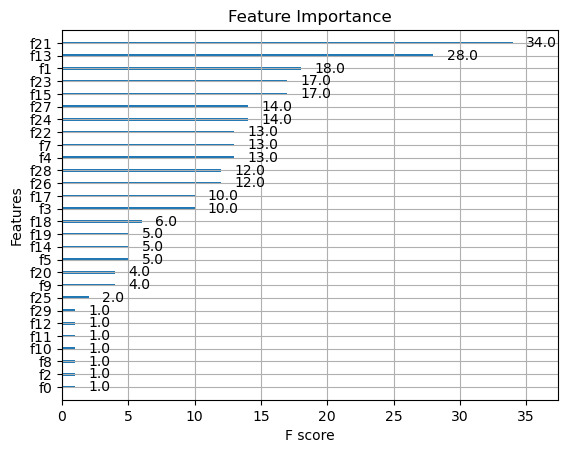

In [7]:

plt.figure(figsize=(10, 6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

In [11]:

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

grid_search = GridSearchCV(xgb.XGBClassifier(eval_metric="logloss"), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"Improved Model Accuracy: {accuracy_best:.10f}")

C:\Users\91636\AppData\Roaming\Python\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Improved Model Accuracy: 0.9736842105


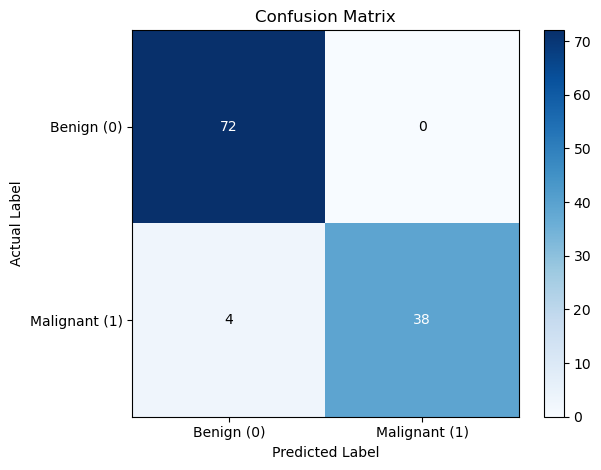

In [12]:
conf_matrix_best = confusion_matrix(y_test, y_pred_best)

plt.imshow(conf_matrix_best, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, labels=["Benign (0)", "Malignant (1)"], rotation=0)
plt.yticks(tick_marks, labels=["Benign (0)", "Malignant (1)"])


thresh = conf_matrix_best.max() / 2.
for i, j in np.ndindex(conf_matrix_best.shape):
    plt.text(j, i, format(conf_matrix[i, j], 'd'),
             ha="center", va="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()